In [3]:
pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 49.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [scikit-learn] [scikit-learn]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [ ]:
# 1. loading dataset with lags

df = pd.read_csv('final_df_with_lags.csv', parse_dates=['data'], index_col='data')
df = df.asfreq('MS') # setting frequency to monthly start

print(df.shape)
df.head()

(295, 4)


,ipca_pct,us_cpi_lag2,us_cpi_lag3,usd_brl_lag4
data,,,,
2000-06-01,0.23,0.058411,0.824499,-1.880826
2000-07-01,1.61,0.116754,0.058411,-1.198756
2000-08-01,1.31,0.524781,0.116754,3.399531
2000-09-01,0.23,0.232019,0.524781,1.101456
2000-10-01,0.14,0.000000,0.232019,-1.456258


In [7]:
print(df.columns.tolist())

['ipca_pct', 'us_cpi_lag2', 'us_cpi_lag3', 'usd_brl_lag4']


In [8]:
# 2. stationarity tests (ADF e KPSS)

def test_stationarity(series, name):
    print(f"\n── {name} ──")
    
    # ADF: H0 = tem raiz unitária (não estacionária)
    adf_stat, adf_p, _, _, adf_crit, _ = adfuller(series.dropna())
    print(f"ADF:  stat={adf_stat:.4f}, p={adf_p:.4f} → {'estacionária ✓' if adf_p < 0.05 else 'não estacionária ✗'}")
    
    # KPSS: H0 = é estacionária
    kpss_stat, kpss_p, _, kpss_crit = kpss(series.dropna(), regression='c', nlags='auto')
    print(f"KPSS: stat={kpss_stat:.4f}, p={kpss_p:.4f} → {'estacionária ✓' if kpss_p > 0.05 else 'não estacionária ✗'}")

for col in ['ipca_pct', 'us_cpi_lag2', 'us_cpi_lag3', 'usd_brl_lag4']:
    test_stationarity(df[col], col)


── ipca_pct ──
ADF:  stat=-8.2876, p=0.0000 → estacionária ✓
KPSS: stat=0.2836, p=0.1000 → estacionária ✓

── us_cpi_lag2 ──
ADF:  stat=-3.3760, p=0.0118 → estacionária ✓
KPSS: stat=0.2103, p=0.1000 → estacionária ✓

── us_cpi_lag3 ──
ADF:  stat=-3.3719, p=0.0120 → estacionária ✓
KPSS: stat=0.2049, p=0.1000 → estacionária ✓

── usd_brl_lag4 ──
ADF:  stat=-10.2449, p=0.0000 → estacionária ✓
KPSS: stat=0.1007, p=0.1000 → estacionária ✓


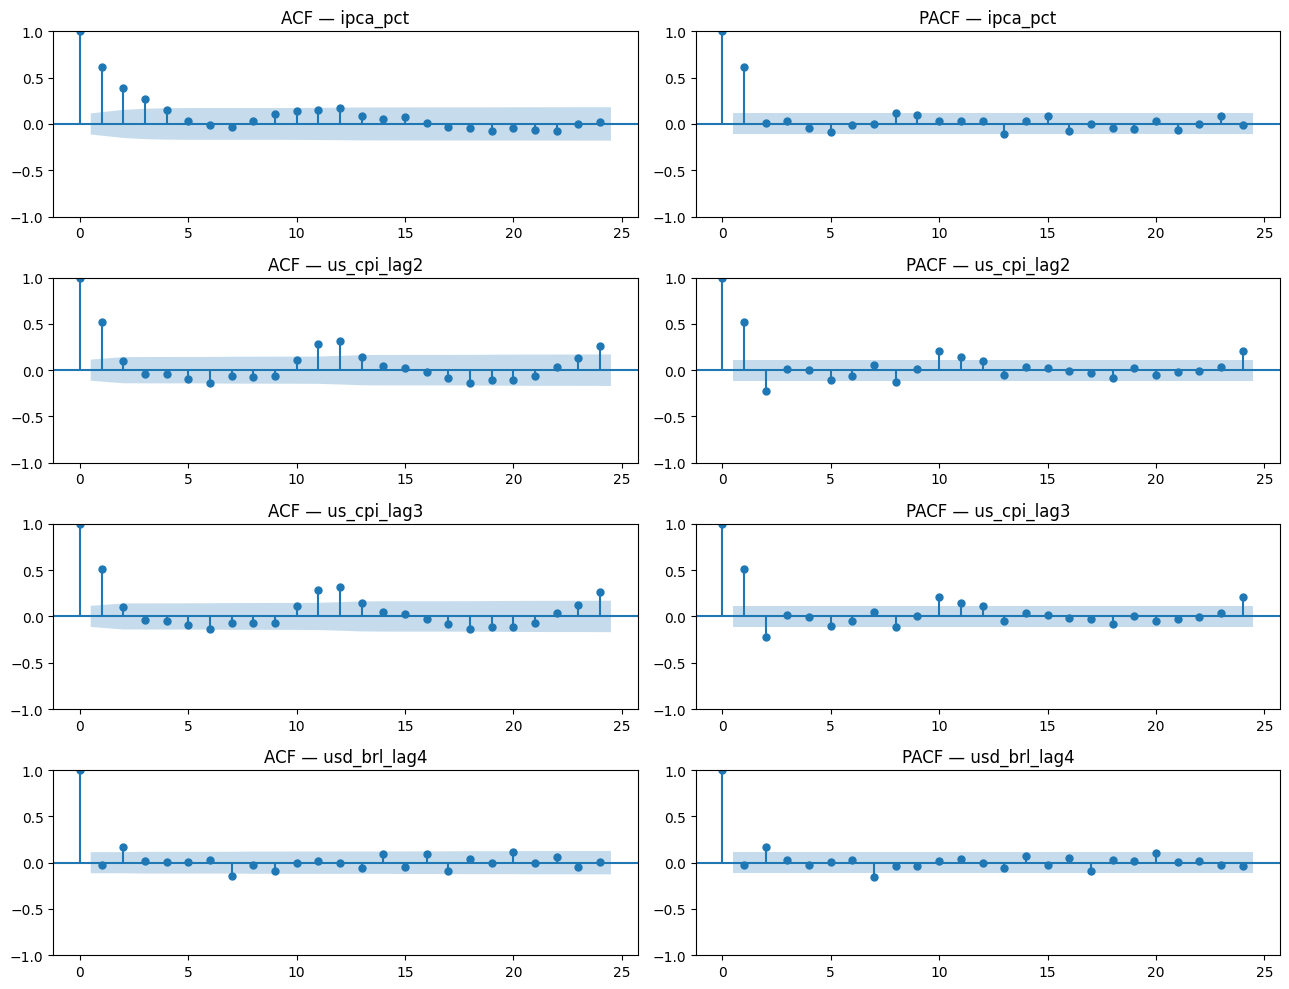

In [10]:
# 3. visual inspection

fig, axes = plt.subplots(4, 2, figsize=(13, 10))

for i, col in enumerate(['ipca_pct', 'us_cpi_lag2', 'us_cpi_lag3', 'usd_brl_lag4']):
    plot_acf(df[col].dropna(),  lags=24, ax=axes[i, 0], title=f'ACF — {col}')
    plot_pacf(df[col].dropna(), lags=24, ax=axes[i, 1], title=f'PACF — {col}')

plt.tight_layout()
plt.savefig('acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# 4.1 test/train and forecast using P, D, Q = 1, 0, 1

# divisão da amostra conforme metodologia
train = df[df.index <  '2020-01-01']
test  = df[df.index >= '2020-01-01']

print(f"Treino: {train.index[0].date()} → {train.index[-1].date()} ({len(train)} obs)")
print(f"Teste:  {test.index[0].date()}  → {test.index[-1].date()}  ({len(test)} obs)")

# ordens identificadas na etapa anterior (ajuste conforme ACF/PACF)
P, D, Q = 1, 0, 1

# ── Modelo 1: só câmbio ──
exog_fx_train = train[['usd_brl_lag4']]
exog_fx_test  = test[['usd_brl_lag4']]

m1 = SARIMAX(train['ipca_pct'], exog=exog_fx_train, order=(P, D, Q),
             enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)

# ── Modelo 2: câmbio + CPI ──
exog_full_train = train[['usd_brl_lag4', 'us_cpi_lag2']]
exog_full_test  = test[['usd_brl_lag4', 'us_cpi_lag2']]

m2 = SARIMAX(train['ipca_pct'], exog=exog_full_train, order=(P, D, Q),
             enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)

print(m1.summary())
print(m2.summary())

Treino: 2000-06-01 → 2019-12-01 (235 obs)
Teste:  2020-01-01  → 2024-12-01  (60 obs)
                               SARIMAX Results                                
Dep. Variable:               ipca_pct   No. Observations:                  235
Model:               SARIMAX(1, 0, 1)   Log Likelihood                 -44.309
Date:                Sat, 18 Apr 2026   AIC                             96.618
Time:                        10:36:54   BIC                            110.422
Sample:                    06-01-2000   HQIC                           102.185
                         - 12-01-2019                                         
Covariance Type:                  opg                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
usd_brl_lag4     0.0100      0.003      2.855      0.004       0.003       0.017
ar.L1            0.8830      0.033     2

In [12]:
# 4.2 test/train and forecast using P, D, Q = 1, 0, 0

# divisão da amostra conforme metodologia
train = df[df.index <  '2020-01-01']
test  = df[df.index >= '2020-01-01']

print(f"Treino: {train.index[0].date()} → {train.index[-1].date()} ({len(train)} obs)")
print(f"Teste:  {test.index[0].date()}  → {test.index[-1].date()}  ({len(test)} obs)")

# ordens identificadas na etapa anterior (ajuste conforme ACF/PACF)
P, D, Q = 1, 0, 0

# ── Modelo 1: só câmbio ──
exog_fx_train = train[['usd_brl_lag4']]
exog_fx_test  = test[['usd_brl_lag4']]

m1 = SARIMAX(train['ipca_pct'], exog=exog_fx_train, order=(P, D, Q),
             enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)

# ── Modelo 2: câmbio + CPI ──
exog_full_train = train[['usd_brl_lag4', 'us_cpi_lag2']]
exog_full_test  = test[['usd_brl_lag4', 'us_cpi_lag2']]

m2 = SARIMAX(train['ipca_pct'], exog=exog_full_train, order=(P, D, Q),
             enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)

print(m1.summary())
print(m2.summary())

Treino: 2000-06-01 → 2019-12-01 (235 obs)
Teste:  2020-01-01  → 2024-12-01  (60 obs)
                               SARIMAX Results                                
Dep. Variable:               ipca_pct   No. Observations:                  235
Model:               SARIMAX(1, 0, 0)   Log Likelihood                 -55.082
Date:                Sat, 18 Apr 2026   AIC                            116.165
Time:                        10:40:12   BIC                            126.531
Sample:                    06-01-2000   HQIC                           120.344
                         - 12-01-2019                                         
Covariance Type:                  opg                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
usd_brl_lag4     0.0100      0.004      2.836      0.005       0.003       0.017
ar.L1            0.8785      0.031     2

In [ ]:
# comment: P, D, Q = 1, 0, 1 has a better fit based on AIC/BIC

In [ ]:
# 4.3 checking if CPI has predictive power with lag 2

P, D, Q = 1, 0, 1

exog_full_train = train[['usd_brl_lag4', 'us_cpi_lag2']]
exog_full_test  = test[['usd_brl_lag4', 'us_cpi_lag2']]

m2 = SARIMAX(train['ipca_pct'], exog=exog_full_train, order=(P, D, Q),
             enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)

print(m2.summary())

                               SARIMAX Results                                
Dep. Variable:               ipca_pct   No. Observations:                  235
Model:               SARIMAX(1, 0, 1)   Log Likelihood                 -43.627
Date:                Sat, 18 Apr 2026   AIC                             97.254
Time:                        10:44:11   BIC                            114.509
Sample:                    06-01-2000   HQIC                           104.212
                         - 12-01-2019                                         
Covariance Type:                  opg                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
usd_brl_lag4     0.0099      0.003      2.901      0.004       0.003       0.017
us_cpi_lag2     -0.0631      0.063     -0.997      0.319      -0.187       0.061
ar.L1            0.8847      0.032     27.25

In [ ]:
## comment: CPI lag 2 has a p-value of 0.08, which is above the common significance threshold of 0.05, suggesting that it may not have strong predictive power for IPCA in this model specification.

In [17]:
# 4.4 checking if CPI has predictive power with lag 3

P, D, Q = 1, 0, 1

exog_full_train = train[['usd_brl_lag4', 'us_cpi_lag3']]
exog_full_test  = test[['usd_brl_lag4', 'us_cpi_lag3']]

m2b = SARIMAX(train['ipca_pct'], exog=exog_full_train, order=(P, D, Q),
             enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)

print(m2.summary())

                               SARIMAX Results                                
Dep. Variable:               ipca_pct   No. Observations:                  235
Model:               SARIMAX(1, 0, 1)   Log Likelihood                 -44.304
Date:                Sat, 18 Apr 2026   AIC                             98.608
Time:                        10:56:25   BIC                            115.863
Sample:                    06-01-2000   HQIC                           105.566
                         - 12-01-2019                                         
Covariance Type:                  opg                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
usd_brl_lag4     0.0099      0.003      2.841      0.004       0.003       0.017
us_cpi_lag3     -0.0057      0.065     -0.088      0.930      -0.133       0.122
ar.L1            0.8839      0.034     26.28

In [ ]:
# conclusão para o ARIMAX

# No contexto do ARIMAX, o CPI não adiciona poder preditivo além do câmbio - nessa estrutura linear autorregressiva, 
# o canal de transmissão da inflação americana para o IPCA já está capturado pelo câmbio, que é o mecanismo de transmissão mais direto.

M1 — só câmbio: MAE=0.5490 | RMSE=0.6325
M2 — câmbio + CPI lag2: MAE=0.5470 | RMSE=0.6301
M2b — câmbio + CPI lag3: MAE=0.5470 | RMSE=0.6300


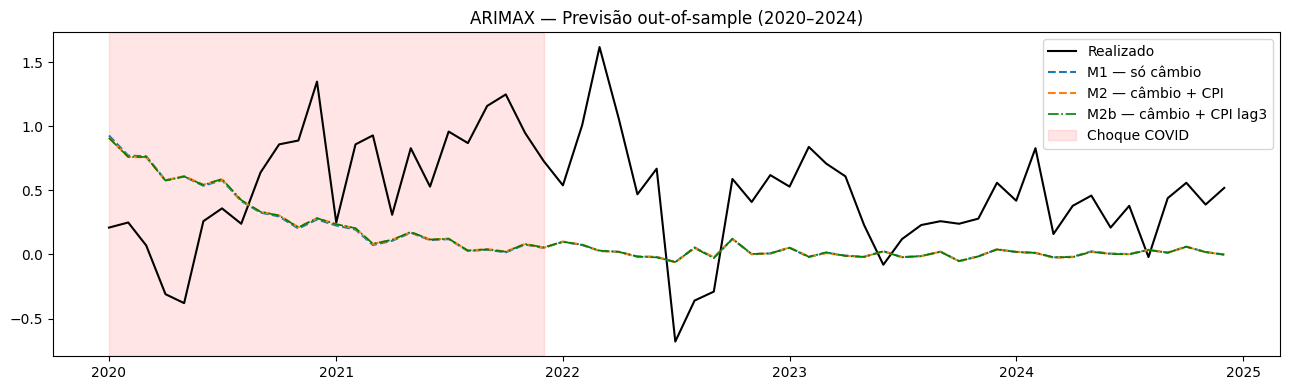

In [19]:
# 5. forecast and evaluation

def evaluate(model, endog_test, exog_test, name):
    pred = model.forecast(steps=len(endog_test), exog=exog_test)
    mae  = mean_absolute_error(endog_test, pred)
    rmse = np.sqrt(mean_squared_error(endog_test, pred))
    print(f"{name}: MAE={mae:.4f} | RMSE={rmse:.4f}")
    return pred

pred_m1  = evaluate(m1,  test['ipca_pct'], test[['usd_brl_lag4']],               'M1 — só câmbio')
pred_m2  = evaluate(m2,  test['ipca_pct'], test[['usd_brl_lag4', 'us_cpi_lag2']], 'M2 — câmbio + CPI lag2')
pred_m2b = evaluate(m2b, test['ipca_pct'], test[['usd_brl_lag4', 'us_cpi_lag3']], 'M2b — câmbio + CPI lag3')

# ── gráfico comparativo ──
plt.figure(figsize=(13, 4))
plt.plot(test.index, test['ipca_pct'], label='Realizado',        color='black')
plt.plot(test.index, pred_m1,          label='M1 — só câmbio',   linestyle='--')
plt.plot(test.index, pred_m2,          label='M2 — câmbio + CPI',linestyle='--')
plt.plot(test.index, pred_m2b,         label='M2b — câmbio + CPI lag3', color='green',    linestyle='-.', linewidth=1.2)
plt.axvspan(pd.Timestamp('2020-01-01'), pd.Timestamp('2021-12-01'),
            alpha=0.1, color='red', label='Choque COVID')
plt.title('ARIMAX — Previsão out-of-sample (2020–2024)')
plt.legend()
plt.tight_layout()
plt.savefig('arimax_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
import pickle

with open('arimax_m1.pkl', 'wb') as f:
    pickle.dump(m1, f)

with open('arimax_m2.pkl', 'wb') as f:
    pickle.dump(m2, f)

with open('arimax_m2b.pkl', 'wb') as f:
    pickle.dump(m2b, f)

In [21]:
results = pd.DataFrame({
    'realizado': test['ipca_pct'].values,
    'pred_m1':   pred_m1.values,
    'pred_m2':   pred_m2.values,
    'pred_m2b':  pred_m2b.values,
}, index=test.index)

results.to_csv('arimax_predictions.csv', index=True)